In [1]:
import io, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt, soundfile as sf
from datasets import load_dataset, Audio
from IPython.display import Audio as Player, display

LABEL_HOP = 512          # each reference label covers 512 samples = 32 ms at 16 kHz

In [2]:
# Stream the dataset so only the first sample is downloaded
dataset = load_dataset("guynich/librispeech_asr_test_vad", split="test.clean", streaming=True)
dataset = dataset.cast_column("audio", Audio(decode=False))
sample = next(iter(dataset))

print("Fields:", list(sample.keys()))
print("File:", sample["file"])
print("Text:", sample["text"])

Fields: ['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id', 'speech', 'confidence']
File: 6930-75918-0000.flac
Text: CONCORD RETURNED TO ITS PLACE AMIDST THE TENTS


In [3]:
audio = sample["audio"]
source = io.BytesIO(audio["bytes"]) if audio["bytes"] is not None else audio["path"]
y, sr = sf.read(source)
if y.ndim > 1:               # convert stereo to mono
    y = y.mean(axis=1)

print("Sample rate:", sr, "Hz | Samples:", len(y), "| Duration:", round(len(y) / sr, 3), "s")
display(Player(y, rate=sr))

Sample rate: 16000 Hz | Samples: 56080 | Duration: 3.505 s


In [4]:
reference = np.asarray(sample["speech"], dtype=int)        # 1 = speech, 0 = non-speech
confidence = np.asarray(sample["confidence"], dtype=int)   # 0 = label is uncertain
valid = confidence == 1                                    # only confident labels are scored

# Each label should correspond to one full 512-sample block
n_blocks = len(y) // LABEL_HOP
assert len(reference) == n_blocks, "Label count does not match the number of 512-sample blocks"
label_times = (np.arange(n_blocks) + 0.5) * LABEL_HOP / sr   # centre time of each label

print("Labels:", len(reference), "| Full 512-sample blocks:", n_blocks)
print("Speech:", int((reference == 1).sum()), "| Non-speech:", int((reference == 0).sum()))
print("Low-confidence labels:", int((~valid).sum()), "| Labels to evaluate:", int(valid.sum()))

Labels: 109 | Full 512-sample blocks: 109
Speech: 82 | Non-speech: 27
Low-confidence labels: 8 | Labels to evaluate: 101


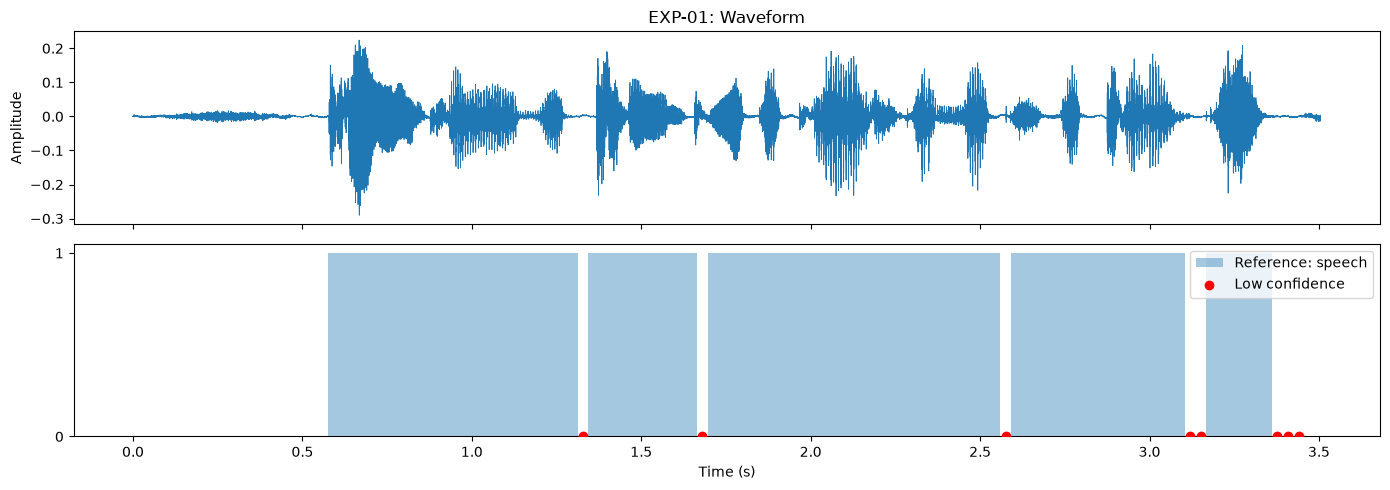

In [5]:
t = np.arange(len(y)) / sr
edges = np.arange(n_blocks + 1) * LABEL_HOP / sr     # block boundaries in seconds

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(t, y, linewidth=0.6)
axes[0].set_title("EXP-01: Waveform"); axes[0].set_ylabel("Amplitude")
axes[1].stairs(reference, edges, fill=True, alpha=0.4, label="Reference: speech")
axes[1].scatter(label_times[~valid], reference[~valid], color="red", zorder=3, label="Low confidence")
axes[1].set_yticks([0, 1]); axes[1].set_xlabel("Time (s)"); axes[1].legend(loc="upper right")
plt.tight_layout(); plt.show()

In [6]:
# One RMS value per label block, so no approximate time matching is needed
blocks = y[:n_blocks * LABEL_HOP].reshape(n_blocks, LABEL_HOP)
rms = np.sqrt(np.mean(blocks ** 2, axis=1))
rms_db = 20 * np.log10(rms + 1e-10)                  # decibel scale

print("RMS range:", rms.min().round(5), "-", rms.max().round(5))
print("Dynamic range:", (rms_db.max() - rms_db.min()).round(1), "dB")

RMS range: 0.00081 - 0.08653
Dynamic range: 40.5 dB


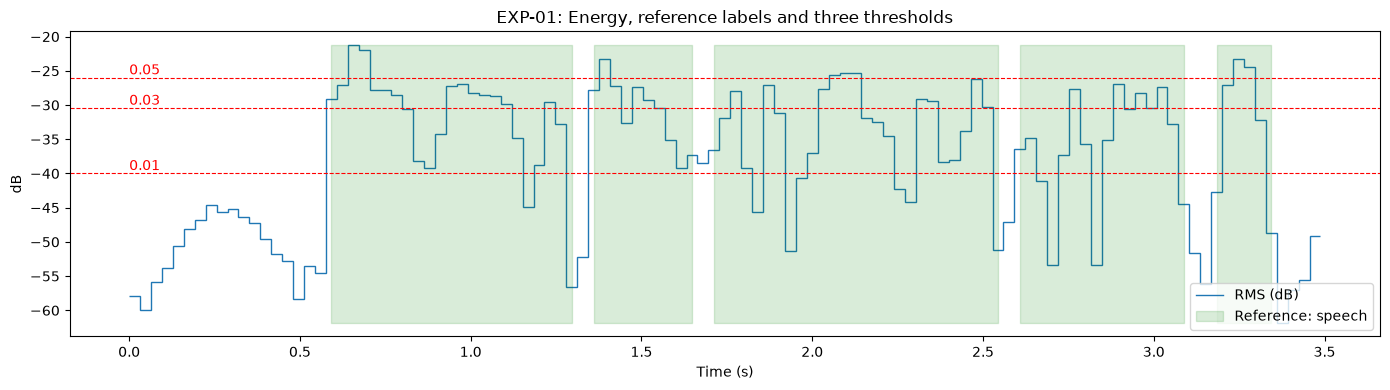

In [7]:
plt.figure(figsize=(14, 4))
plt.stairs(rms_db, edges, baseline=None, label="RMS (dB)")
plt.fill_between(label_times, rms_db.min(), rms_db.max(), where=reference == 1,
                 step="mid", alpha=0.15, color="green", label="Reference: speech")
for th in [0.01, 0.03, 0.05]:
    plt.axhline(20 * np.log10(th), color="red", linestyle="--", linewidth=0.8)
    plt.text(0, 20 * np.log10(th) + 0.5, f"{th}", color="red")
plt.xlabel("Time (s)"); plt.ylabel("dB"); plt.title("EXP-01: Energy, reference labels and three thresholds")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

Loudest non-speech label: -44.5 dB
Quietest speech label   : -56.6 dB
Speech labels overlapping with non-speech: 8 / 82


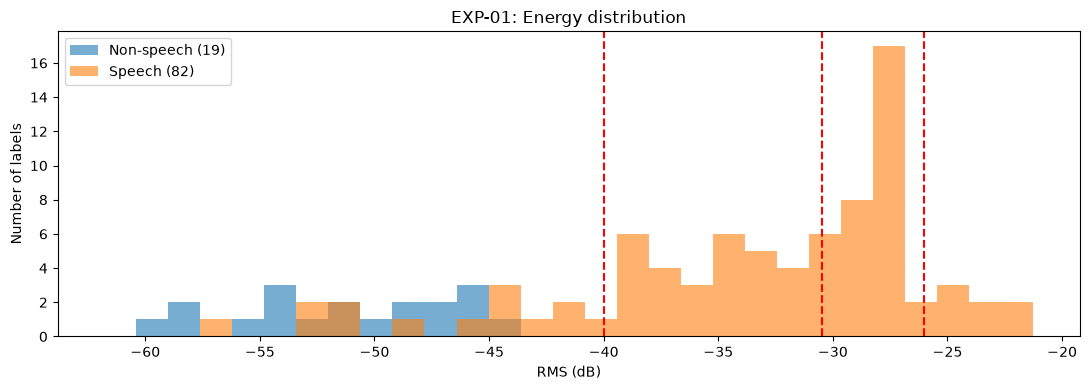

In [8]:
speech_db = rms_db[valid & (reference == 1)]
silence_db = rms_db[valid & (reference == 0)]

bins = np.linspace(rms_db.min(), rms_db.max(), 30)
plt.figure(figsize=(11, 4))
plt.hist(silence_db, bins=bins, alpha=0.6, label=f"Non-speech ({len(silence_db)})")
plt.hist(speech_db, bins=bins, alpha=0.6, label=f"Speech ({len(speech_db)})")
for th in [0.01, 0.03, 0.05]:
    plt.axvline(20 * np.log10(th), color="red", linestyle="--")
plt.xlabel("RMS (dB)"); plt.ylabel("Number of labels"); plt.title("EXP-01: Energy distribution")
plt.legend(); plt.tight_layout(); plt.show()

# Speech labels that are no louder than the loudest non-speech label:
# no single threshold can separate these from silence
overlap = int(np.sum(speech_db <= silence_db.max()))
print("Loudest non-speech label:", silence_db.max().round(1), "dB")
print("Quietest speech label   :", speech_db.min().round(1), "dB")
print("Speech labels overlapping with non-speech:", overlap, "/", len(speech_db))

In [9]:
def metrics(true, pred):
    tp = int(np.sum((true == 1) & (pred == 1))); tn = int(np.sum((true == 0) & (pred == 0)))
    fp = int(np.sum((true == 0) & (pred == 1))); fn = int(np.sum((true == 1) & (pred == 0)))
    miss = fn / (tp + fn) if tp + fn else np.nan          # share of speech that was cut
    fa = fp / (fp + tn) if fp + tn else np.nan            # share of non-speech called speech
    precision = tp / (tp + fp) if tp + fp else np.nan
    recall = 1 - miss
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else np.nan
    return {"miss_rate": miss, "false_alarm_rate": fa, "balanced_accuracy": 1 - (miss + fa) / 2,
            "precision": precision, "recall": recall, "f1": f1, "TP": tp, "TN": tn, "FP": fp, "FN": fn}

true = reference[valid]

def evaluate(threshold):
    """Score a fixed RMS threshold on the confident labels."""
    return metrics(true, (rms[valid] > threshold).astype(int))

first_table = pd.DataFrame({th: evaluate(th) for th in [0.01, 0.03, 0.05]}).T
first_table.index.name = "threshold"
display(first_table.round(3))

,miss_rate,false_alarm_rate,balanced_accuracy,precision,recall,f1,TP,TN,FP,FN
threshold,,,,,,,,,,
0.01,0.171,0.0,0.915,1.0,0.829,0.907,68.0,19.0,0.0,14.0
0.03,0.537,0.0,0.732,1.0,0.463,0.633,38.0,19.0,0.0,44.0
0.05,0.902,0.0,0.549,1.0,0.098,0.178,8.0,19.0,0.0,74.0


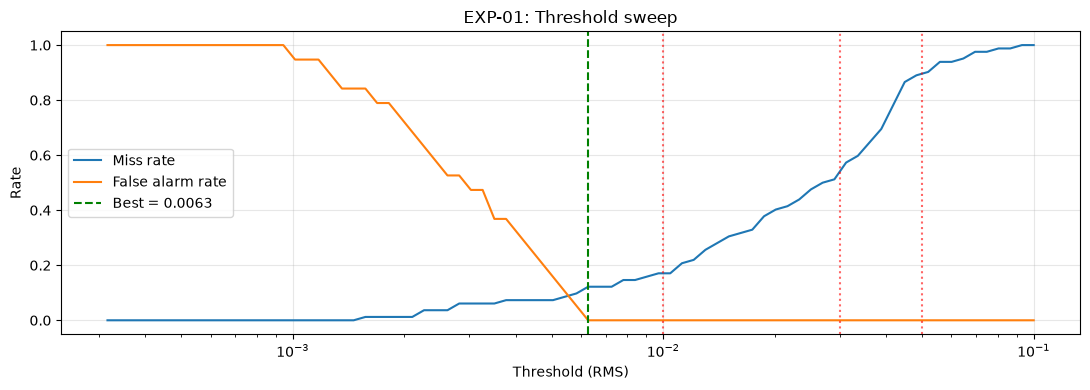

,threshold,miss_rate,false_alarm_rate,balanced_accuracy,f1,FP,FN
41,0.0063,0.122,0.0,0.939,0.9351,0,10


In [10]:
# 80 thresholds on a log scale instead of three hand-picked values
thresholds = np.logspace(-3.5, -1, 80)
sweep = pd.DataFrame([{"threshold": th, **evaluate(th)} for th in thresholds])
best = sweep["balanced_accuracy"].idxmax()
best_th = sweep.loc[best, "threshold"]

plt.figure(figsize=(11, 4))
plt.semilogx(sweep["threshold"], sweep["miss_rate"], label="Miss rate")
plt.semilogx(sweep["threshold"], sweep["false_alarm_rate"], label="False alarm rate")
plt.axvline(best_th, color="green", linestyle="--", label=f"Best = {best_th:.4f}")
for th in [0.01, 0.03, 0.05]:
    plt.axvline(th, color="red", linestyle=":", alpha=0.6)
plt.xlabel("Threshold (RMS)"); plt.ylabel("Rate"); plt.title("EXP-01: Threshold sweep")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

display(sweep.loc[[best], ["threshold", "miss_rate", "false_alarm_rate", "balanced_accuracy", "f1", "FP", "FN"]].round(4))

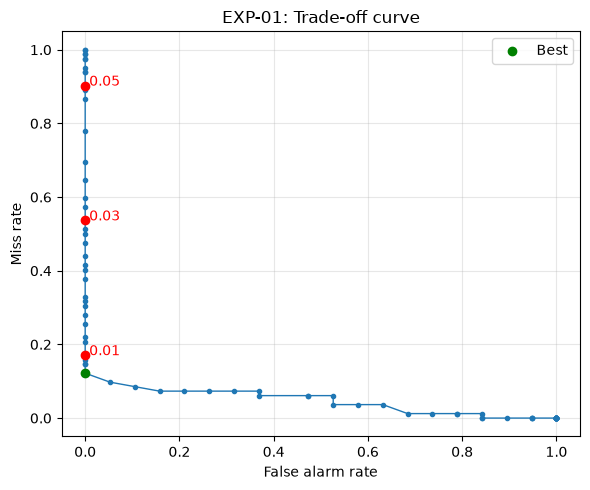

In [11]:
plt.figure(figsize=(6, 5))
plt.plot(sweep["false_alarm_rate"], sweep["miss_rate"], marker=".", linewidth=1)
for th in [0.01, 0.03, 0.05]:
    m = evaluate(th)
    plt.scatter(m["false_alarm_rate"], m["miss_rate"], color="red", zorder=3)
    plt.annotate(f" {th}", (m["false_alarm_rate"], m["miss_rate"]), color="red")
plt.scatter(sweep.loc[best, "false_alarm_rate"], sweep.loc[best, "miss_rate"], color="green", zorder=3, label="Best")
plt.xlabel("False alarm rate"); plt.ylabel("Miss rate")
plt.title("EXP-01: Trade-off curve"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Missed label times (s)     : [1.17 1.3  1.84 1.94 2.29 2.54 2.7  2.83 3.09 3.34]
False alarm label times (s): []


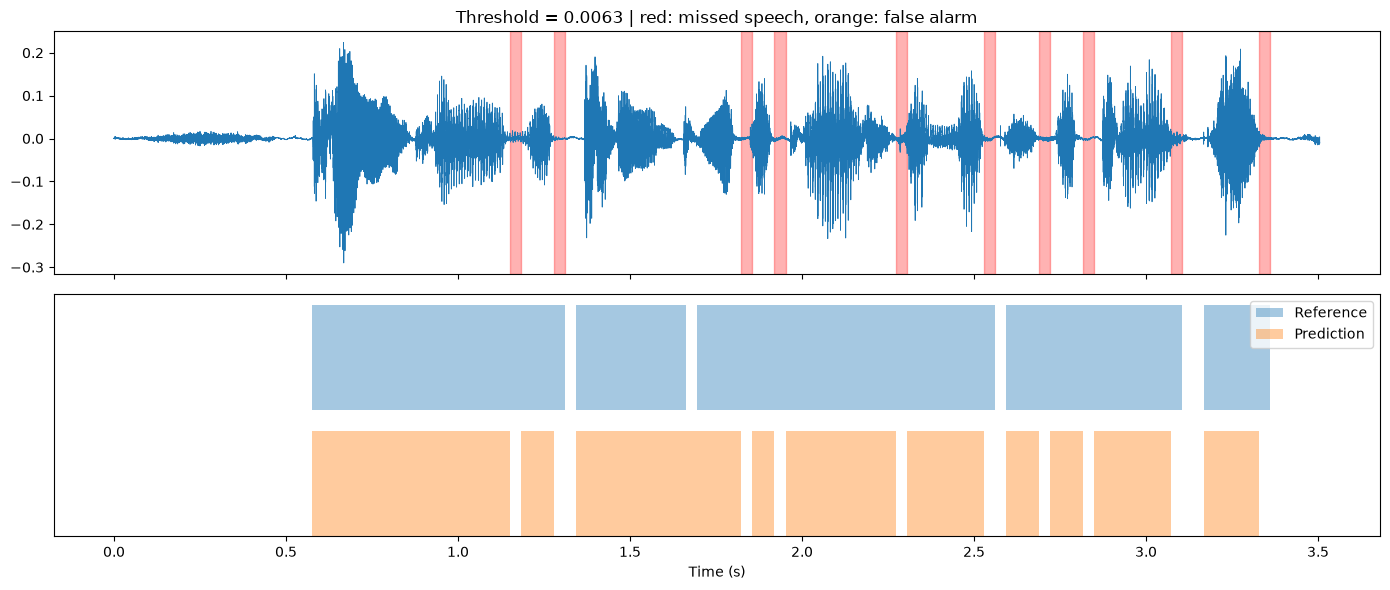

In [12]:
pred = (rms > best_th).astype(int)
missed = valid & (reference == 1) & (pred == 0)          # speech that was cut
false_alarms = valid & (reference == 0) & (pred == 1)    # non-speech called speech

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t, y, linewidth=0.6)
for i in np.where(missed)[0]:
    axes[0].axvspan(edges[i], edges[i + 1], color="red", alpha=0.3)
for i in np.where(false_alarms)[0]:
    axes[0].axvspan(edges[i], edges[i + 1], color="orange", alpha=0.4)
axes[0].set_title(f"Threshold = {best_th:.4f} | red: missed speech, orange: false alarm")
axes[1].stairs(reference + 1.2, edges, baseline=1.2, fill=True, alpha=0.4, label="Reference")
axes[1].stairs(pred, edges, fill=True, alpha=0.4, label="Prediction")
axes[1].set_yticks([]); axes[1].set_xlabel("Time (s)"); axes[1].legend(loc="upper right")
plt.tight_layout(); plt.show()

print("Missed label times (s)     :", np.round(label_times[missed], 2))
print("False alarm label times (s):", np.round(label_times[false_alarms], 2))

In [13]:
def runs(mask):
    """Return (start, end) index pairs of consecutive True regions; end is exclusive."""
    padded = np.concatenate([[0], mask.astype(int), [0]])
    change = np.diff(padded)
    return list(zip(np.where(change == 1)[0], np.where(change == -1)[0]))

speech_runs = runs(reference == 1)
rows = []
for start, end in runs(missed):
    # Find the reference speech segment that contains this missed region
    seg = next(((s, e) for s, e in speech_runs if s <= start < e), (start, end))
    if start == seg[0]:
        position = "speech onset"
    elif end == seg[1]:
        position = "speech offset"
    else:
        position = "inside speech"
    rows.append({"start_s": edges[start], "end_s": edges[end], "n_labels": end - start,
                 "position": position, "mean_dB": rms_db[start:end].mean()})
missed_table = pd.DataFrame(rows)
display(missed_table.round(2))

,start_s,end_s,n_labels,position,mean_dB
0,1.15,1.18,1,inside speech,-44.88
1,1.28,1.31,1,speech offset,-56.62
2,1.82,1.86,1,inside speech,-45.57
3,1.92,1.95,1,inside speech,-51.38
4,2.27,2.30,1,inside speech,-44.20
5,2.53,2.56,1,speech offset,-51.13
6,2.69,2.72,1,inside speech,-53.32
7,2.82,2.85,1,inside speech,-53.35
8,3.07,3.10,1,speech offset,-44.43
9,3.33,3.36,1,speech offset,-48.65


In [14]:
margin = int(0.3 * sr)       # add 0.3 s of context before and after each region
for _, row in missed_table.iterrows():
    a = max(0, int(row["start_s"] * sr) - margin)
    b = min(len(y), int(row["end_s"] * sr) + margin)
    print(f"{row['start_s']:.2f}-{row['end_s']:.2f} s | {row['position']}")
    display(Player(y[a:b], rate=sr))

1.15-1.18 s | inside speech
1.28-1.31 s | speech offset
1.82-1.86 s | inside speech
1.92-1.95 s | inside speech
2.27-2.30 s | inside speech
2.53-2.56 s | speech offset
2.69-2.72 s | inside speech
2.82-2.85 s | inside speech
3.07-3.10 s | speech offset
3.33-3.36 s | speech offset


In [15]:
with_valid = evaluate(best_th)
with_all = metrics(reference, (rms > best_th).astype(int))
display(pd.DataFrame({"confident labels only": with_valid, "all labels": with_all}).T[
    ["miss_rate", "false_alarm_rate", "balanced_accuracy", "FP", "FN"]].round(3))
print("Low-confidence label times (s):", np.round(label_times[~valid], 2))

Low-confidence label times (s): [1.33 1.68 2.58 3.12 3.15 3.38 3.41 3.44]


,miss_rate,false_alarm_rate,balanced_accuracy,FP,FN
confident labels only,0.122,0.000,0.939,0.0,10.0
all labels,0.122,0.037,0.921,1.0,10.0


In [16]:
# The common 25 ms / 10 ms framing, matched to labels by nearest time (approximate),
# compared with the exact 32 ms label grid used above
frame_length, hop_length = 400, 160
n_frames = 1 + (len(y) - frame_length) // hop_length
idx = np.arange(frame_length)[None, :] + hop_length * np.arange(n_frames)[:, None]
rms_frames = np.sqrt(np.mean(y[idx] ** 2, axis=1))
frame_times = (np.arange(n_frames) * hop_length + frame_length / 2) / sr

approx_times = (np.arange(n_blocks) + 0.5) * (len(y) / sr) / n_blocks
nearest = np.abs(frame_times[:, None] - approx_times[None, :]).argmin(axis=0)

rows = []
for th in [0.01, 0.03, 0.05, best_th]:
    approx = metrics(true, (rms_frames[nearest][valid] > th).astype(int))
    exact = evaluate(th)
    rows.append({"threshold": round(th, 4),
                 "miss (25 ms, approx)": approx["miss_rate"], "miss (32 ms, exact)": exact["miss_rate"],
                 "false alarm (25 ms, approx)": approx["false_alarm_rate"],
                 "false alarm (32 ms, exact)": exact["false_alarm_rate"]})
display(pd.DataFrame(rows).round(3))
print("Largest time offset of the approximate grid (ms):", (np.abs(approx_times - label_times).max() * 1000).round(1))

Largest time offset of the approximate grid (ms): 16.9


,threshold,"miss (25 ms, approx)","miss (32 ms, exact)","false alarm (25 ms, approx)","false alarm (32 ms, exact)"
0,0.010,0.195,0.171,0.0,0.0
1,0.030,0.549,0.537,0.0,0.0
2,0.050,0.902,0.902,0.0,0.0
3,0.006,0.146,0.122,0.0,0.0


In [17]:
# Bootstrap: resample the labels with replacement 2000 times
rng = np.random.default_rng(42)
pred_valid = (rms[valid] > best_th).astype(int)
boot = []
for _ in range(2000):
    i = rng.integers(0, len(true), len(true))
    m = metrics(true[i], pred_valid[i])
    boot.append([m["miss_rate"], m["false_alarm_rate"]])
low, high = np.nanpercentile(np.array(boot), [2.5, 97.5], axis=0)

print(f"Miss rate       : {with_valid['miss_rate']:.3f}  (95% interval {low[0]:.3f} - {high[0]:.3f})")
print(f"False alarm rate: {with_valid['false_alarm_rate']:.3f}  (95% interval {low[1]:.3f} - {high[1]:.3f})")

Miss rate       : 0.122  (95% interval 0.055 - 0.200)
False alarm rate: 0.000  (95% interval 0.000 - 0.000)


In [18]:
os.makedirs("../results", exist_ok=True)
sweep.to_csv("../results/exp01_threshold_sweep.csv", index=False)
first_table.to_csv("../results/exp01_three_thresholds.csv")
print("Saved.")

Saved.
